In [1]:
import pandas as pd
import numbers as np

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics._regression import root_mean_squared_error
from sklearn.pipeline import Pipeline
import seaborn as sns

In [2]:
df = pd.read_csv('data/winequality-red.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


<Axes: xlabel='quality', ylabel='count'>

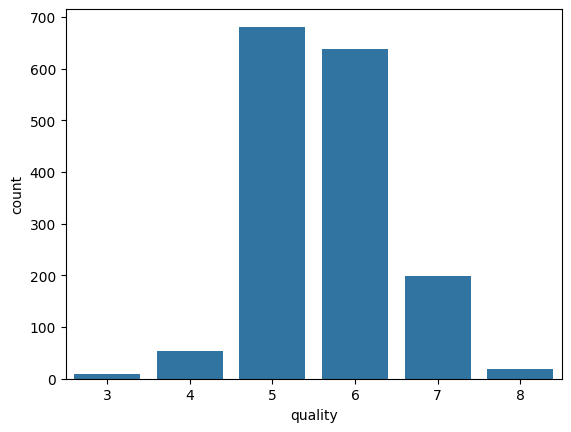

In [4]:
sns.countplot(data=df, x='quality')

<Axes: >

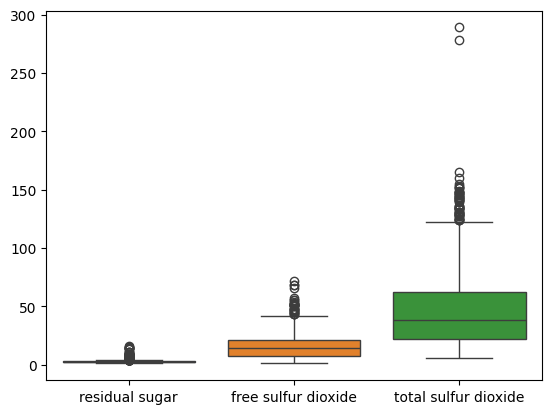

In [5]:
keys = ['residual sugar', 'free sulfur dioxide', 'total sulfur dioxide']

sns.boxplot(df[keys])

In [6]:
for key in keys:
    print(f'{key} 1% quantile = {df[key].quantile(0.99)}')

residual sugar 1% quantile = 8.305999999999996
free sulfur dioxide 1% quantile = 50.01999999999998
total sulfur dioxide 1% quantile = 145.0


<Axes: ylabel='Count'>

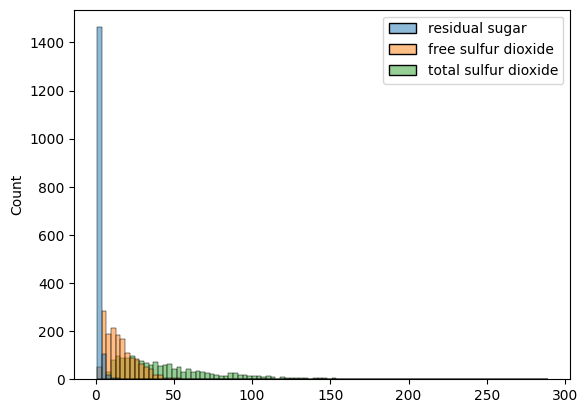

In [7]:
sns.histplot(df[keys])

<Axes: >

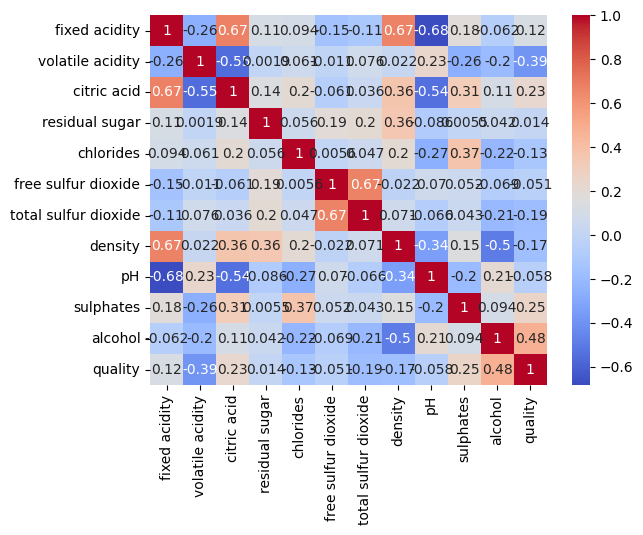

In [8]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

<Axes: xlabel='quality', ylabel='alcohol'>

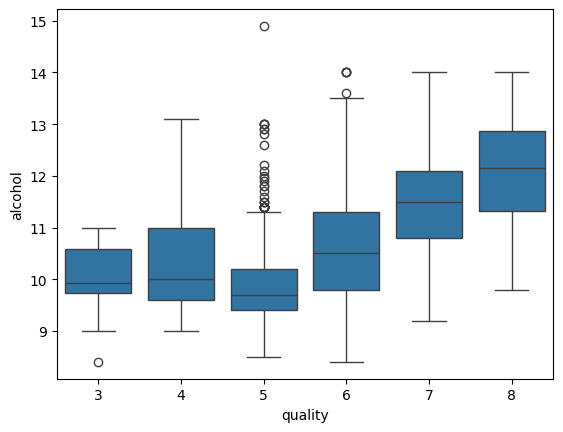

In [9]:
sns.boxplot(data=df, x='quality', y='alcohol')

<Axes: xlabel='quality', ylabel='volatile acidity'>

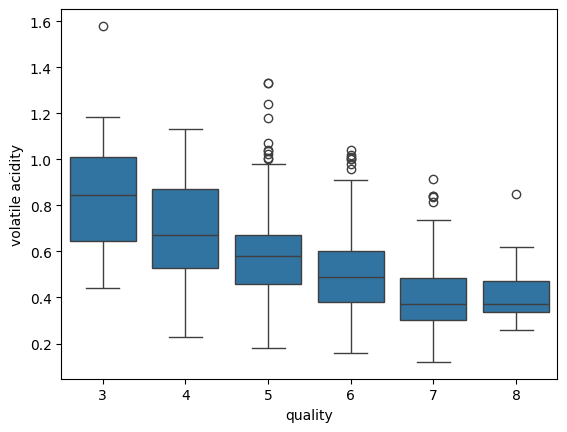

In [10]:
sns.boxplot(data=df, x='quality', y='volatile acidity')

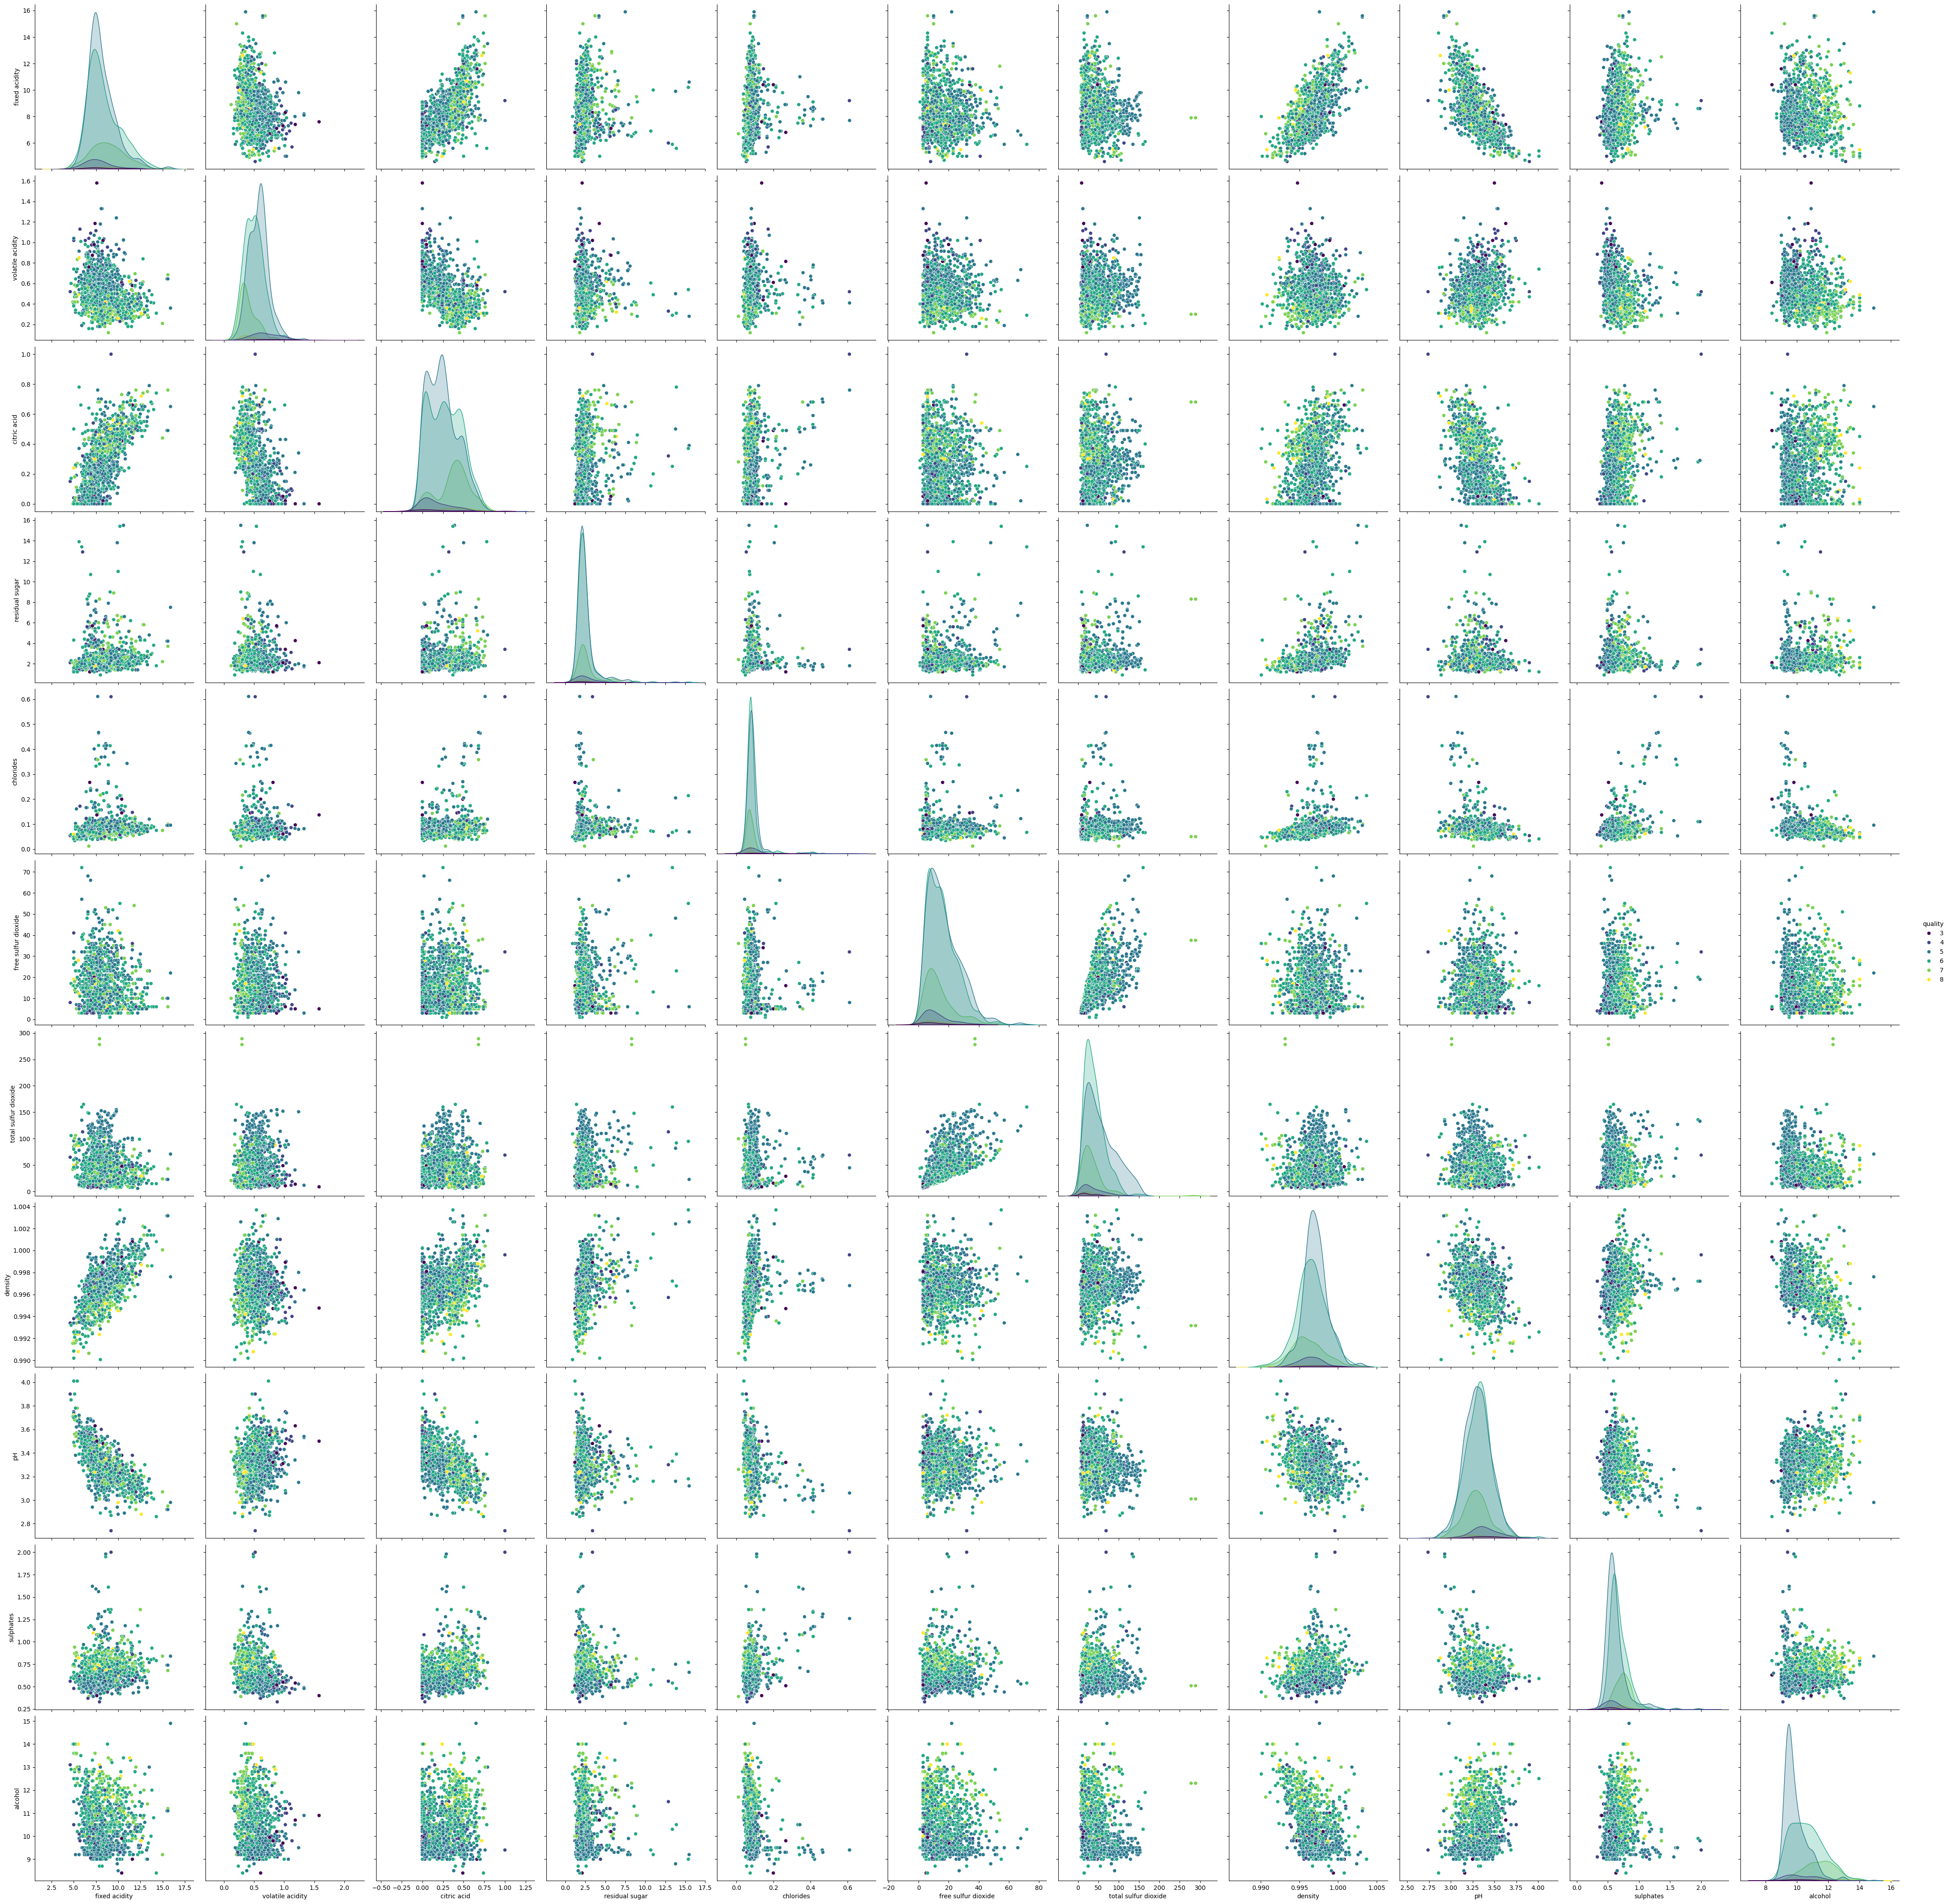

In [11]:
sns.pairplot(df, hue='quality', height=4, palette='viridis')

<Axes: xlabel='alcohol', ylabel='Count'>

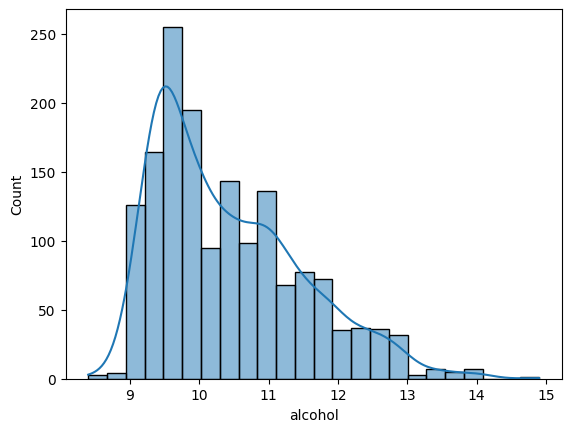

In [12]:
sns.histplot(data=df, x='alcohol', kde=True)

In [ ]:
import mlflow
import mlflow.sklearn
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np

RANDOM_STATE = 42

X = df.drop('quality', axis=1)
y = df['quality']


x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, shuffle=True)


models_and_params = {
    'LinearRegression': {
        'estimator': Pipeline([
            ('standard', StandardScaler()),
            ('lr', LinearRegression())
        ]),
        'param_grid': {
            'lr__fit_intercept': [True, False]
        }
    },
    'RandomForestRegressor': {
        'estimator': Pipeline([
            ('standard', StandardScaler()),
            ('rf', RandomForestRegressor(random_state=RANDOM_STATE))
        ]),
        'param_grid': {
            'rf__n_estimators': [50, 100, 200],
            'rf__max_depth': [None, 10, 20],
            'rf__min_samples_split': [2, 5, 10]
        }
    }
}


experiment_name = 'Regression Models Experiment'
mlflow.set_experiment(experiment_name)
mlflow.sklearn.autolog(max_tuning_runs=20)
results = []

for name, config in models_and_params.items():
    estimator = config['estimator']
    grid = GridSearchCV(
        estimator=estimator,
        param_grid=config['param_grid'],
        cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
    )
    
    with mlflow.start_run(run_name=f'{name}_GridSearch', nested=True) as run:
        grid.fit(x_train, y_train)
        mlflow.log_param('random_state', RANDOM_STATE)

        best_model = grid.best_estimator_
        best_params = grid.best_params_
        

        y_pred = best_model.predict(x_test)
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        

        mlflow.log_params(best_params)
        mlflow.log_metrics({'test_mse': mse, 'test_r2': r2})
        mlflow.sklearn.log_model(best_model, 'model')
        

        results.append({
            'Model': name,
            'Best Params': best_params,
            'Best CV MSE': -grid.best_score_,
            'Test MSE': mse,
            'Test R2': r2
        })
        
        print(f'{name} - Best Params: {best_params}, Test MSE: {mse:.4f}, Test R2: {r2:.4f}')


2025/11/05 23:33:46 INFO mlflow.sklearn.utils: Logging the 20 best runs, no runs will be omitted.
2025/11/05 23:33:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/05 23:33:48 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


LinearRegression - Best Params: {'lr__fit_intercept': True}, Test MSE: 0.3900, Test R2: 0.4032


2025/11/05 23:33:59 INFO mlflow.sklearn.utils: Logging the 20 best runs, 7 runs will be omitted.
2025/11/05 23:33:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/05 23:34:01 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


RandomForestRegressor - Best Params: {'rf__max_depth': None, 'rf__min_samples_split': 2, 'rf__n_estimators': 200}, Test MSE: 0.3063, Test R2: 0.5312

Сравнение моделей:
                   Model                                        Best Params  \
0       LinearRegression                        {'lr__fit_intercept': True}   
1  RandomForestRegressor  {'rf__max_depth': None, 'rf__min_samples_split...   

   Best CV MSE  Test MSE   Test R2  
0     0.440056  0.390025  0.403180  
1     0.367658  0.306349  0.531222  
